# Classification with US Airline Sentiment Tweets

## Imports

In [ ]:
'''General'''
import sys
import os
import ast
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
'''Data'''
import pandas as pd
import numpy as np
"""Preprocessing"""
import nltk
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import torch
'''Visualization'''
import seaborn as sns
import matplotlib.pyplot as plt
'''Local'''
from src.lstm_classifier import *
from src.utils import *
from src.nn_utils import *

# sns.set_palette("deep")
sns.set_theme(context='paper',
              style='white',
              font_scale=1.5,
              palette='viridis')

pd.set_option('display.max_columns', 200)


import gensim
import gensim.downloader as api


## Data Preprocessing

In [2]:
filepath = "../data/02_processed/Tweets.csv"

tweets_df = pd.read_csv(filepath)
tweets_df.head(20)

,Unnamed: 0,airline_sentiment,text,tokens
0,0,neutral,what said,['say']
1,1,positive,plus you have added commercials to the experie...,"['plus', 'add', 'commercial', 'experience', 't..."
2,2,neutral,i did not today must mean i need to take anoth...,"['today', 'must', 'mean', 'need', 'take', 'ano..."
3,3,negative,it is really aggressive to blast obnoxious ent...,"['really', 'aggressive', 'blast', 'obnoxious',..."
4,4,negative,and it is a really big bad thing about it,"['really', 'big', 'bad', 'thing']"
5,5,negative,seriously would pay a flight for seats that di...,"['seriously', 'would', 'pay', 'flight', 'seat'..."
6,6,positive,yes nearly every time i fly vx this ear worm w...,"['yes', 'nearly', 'every', 'time', 'fly', 'vx'..."
7,7,neutral,really missed a prime opportunity for men with...,"['really', 'miss', 'prime', 'opportunity', 'me..."
8,8,positive,well i did not but now i do d,['well']
9,9,positive,it was amazing and arrived an hour early you a...,"['amazing', 'arrive', 'hour', 'early', 'good']"


In [3]:
tweets_df['tokens'] = tweets_df['tokens'].apply(ast.literal_eval)

In [4]:
tweets_df

,Unnamed: 0,airline_sentiment,text,tokens
0,0,neutral,what said,[say]
1,1,positive,plus you have added commercials to the experie...,"[plus, add, commercial, experience, tacky]"
2,2,neutral,i did not today must mean i need to take anoth...,"[today, must, mean, need, take, another, trip]"
3,3,negative,it is really aggressive to blast obnoxious ent...,"[really, aggressive, blast, obnoxious, enterta..."
4,4,negative,and it is a really big bad thing about it,"[really, big, bad, thing]"
...,...,...,...,...
14635,14635,positive,thank you we got on a different flight to chicago,"[thank, get, different, flight, chicago]"
14636,14636,negative,leaving over minutes late flight no warnings o...,"[leave, minute, late, flight, warning, communi..."
14637,14637,neutral,please bring american airlines to,"[please, bring, american, airline]"
14638,14638,negative,you have my money you change my flight and do ...,"[money, change, flight, answer, phone, suggest..."


**Introduction**

The following analysis utilizes the implementation of an LSTM neural network in
order to perform a sentiment classification of the 'US Airline Tweets' datasset into three 
classes ['Neutral', 'Negative', 'Positive']. 

The dataset that is used contains an already cleaned text in the form 
of tokens.

**From tokenized text to proper model input**


LSTM neural networks process inputs in batches and require all sequences in a batch to have the same
length, so the input forms a rectangular tensor. For this reason the tokenized tweets must first be
mapped from a string format to int format. In order to do that, we create a vocabulary with words
from the train dataset, that appear at least min_frequency times. Then a dictionary is
created, containing the above vocabulary as keys an an index assigned to it. The dictionary also
contains the <pad> with key=0 and <ukn> with key=1 to handle unknown words during mapping and
padding. 

The next step requires to parse the tokens of each
tweet and map the words with their respective ID from our dictionary. As each 
tweet has a different length of words, we now have to bring all the 'tweets' into a 
similar length. We pad the remaining missing indexes with zeros. If a tweet 
is larger than the specified length we slice it. 


The dataset is ready for input. So far we went from 

Example:

    [really, big, bad, thing] -> [50, 60, 70, 80, 0..., 0]

    shape: [1, 4]                   shape [1, seq_len]

Now the dataset has a shape of *[number_of_tweets, seq_len]*


The IDs that now represent the previously string tokens, work as indexes. 
In order for our model to give meaning to the input batches we need two things:
- and embedding layer for our model
- an embedding matrix with shape *[ number_of_voc_words, embedding_size]*

The embedding matrix is constructed from an already pre-trained model.
For the current analysis the *glove-twitter-100* was used.
Each row represents a word from our vocabulary.

For example: 
    flight has an ID=2 

    the embedding_matrix[2] contains the embedding of the word flight.

Now the input batch will go through the *embedding layer* with shape 
    [batch_size, seq_len]
    (seq_len is the length of a padded tweet, for example 40)

Then the layer will map each word_ID from input batch 
to its respective embedding from the embedding matrix. 
The output of the *embedding_layer* will now have a shape:

    [batch_size, seq_len, embedding_size]
    

**Model Architecture**

The LSTM model that was implemented in this analysis, has the following architecture:
- an embedding layer
- a dropout layer (regularization)
- a bi-LSTM layer
- a dropout layer (regularization)
- an attention layer (optional)
- a final Linear layer working as the final classifier
(when attention is disabled, mean pooling over the sequence dimension is used in its place)

The pretrained embeddings were kept frozen during training, meaning their values were not updated by gradient descent.


## Train Test Split

In [5]:
# Label Encoding
le_ann = LabelEncoder()
tweets_df['label'] = le_ann.fit_transform(tweets_df['airline_sentiment'])

# Split Train, Test
X_train, X_test, y_train, y_test = train_test_split(
    tweets_df['tokens'], tweets_df['label'],
    test_size=0.2,
    random_state=42,
    stratify=tweets_df['label']
)

# Split Train, Val
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size = 0.125, random_state=42
)


In [6]:
# Convert to np.ndarray
y_train_vec = np.array(y_train, dtype=np.float32)
y_test_vec = np.array(y_test, dtype=np.float32)
y_val_vec = np.array(y_val, dtype=np.float32)

In [7]:
print("\n------ X sample shapes: ------")
print("\nX train shape: ", X_train.shape)
print("X test shape:  ", X_test.shape)
print("X val shape:   ", X_val.shape)


print("\n------ Y sample shapes: ------")
print("\ny train shape: ", y_train.shape)
print("y test shape:  ", y_test.shape)
print("y val shape:   ", y_val.shape)


------ X sample shapes: ------

X train shape:  (10248,)
X test shape:   (2928,)
X val shape:    (1464,)

------ Y sample shapes: ------

y train shape:  (10248,)
y test shape:   (2928,)
y val shape:    (1464,)


In [ ]:
# Load Glove twitter model
# glove = api.load("glove-twitter-100")
# glove.save('glove_100d.kv')              # → ~150 MB binary file

In [ ]:
# Load already local saved glove model
from gensim.models import KeyedVectors
glove = KeyedVectors.load('glove_100d.kv')

In [ ]:
# Create vocabulary from the
# training dataset
vocabulary = get_vocabulary(X_train)
word2id = set_words_2ids(vocabulary)

# Specify the seq_len
max_words = 40

# Transform tokens to int IDs and pad
X_train_ids = pad_sequences(X_train, word2id, max_words=max_words)
X_val_ids = pad_sequences(X_val, word2id, max_words=max_words)
X_test_ids = pad_sequences(X_test, word2id, max_words=max_words)

# Create the embedding matrix
embedding_matrix = create_embedding_matrix(glove, word2id, dim=100)

## Analysis with LSTM

### Initialization

In [ ]:
# =============================================================================
# Create Datasets & DataLoaders
# =============================================================================

DEVICE = 'cpu'

torch.manual_seed(42)

batch_size = 128

train_dataset = EmbeddingsDataset(X_train_ids, y_train_vec, device=DEVICE)
test_dataset = EmbeddingsDataset(X_test_ids, y_test_vec, device=DEVICE)
val_dataset = EmbeddingsDataset(X_val_ids, y_val_vec, device=DEVICE)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# =============================================================================
# Model definition
# =============================================================================
hidden_dimension = 128
output_dimension = 3
embedding_matrix = torch.FloatTensor(embedding_matrix, device=DEVICE)
dropout = [0.2, 0.3, 0.3]

# Model with attention layer
wa_model = LSTMClassifier(
    hidden_dimension,
    output_dimension,
    embedding_matrix,
    num_layers=2,
    dropout=dropout,
    bidirectional=True,
    attention=True
).to(DEVICE)

# Mode without attention layer
na_model = LSTMClassifier(
    hidden_dimension,
    output_dimension,
    embedding_matrix,
    num_layers=2,
    dropout=dropout,
    bidirectional=True,
    attention=False
).to(DEVICE)

# =============================================================================
# Loss and Optimizer Definition
# =============================================================================

criterion = nn.CrossEntropyLoss()

# Optimizer for the with_attention model
wa_optimizer = torch.optim.Adam(wa_model.parameters(), lr=1e-4, weight_decay=1e-4)
# Optimizer for the with_no_attention model
na_optimizer = torch.optim.Adam(na_model.parameters(), lr=1e-4, weight_decay=1e-4)

# Number of training epochs
epochs = 200

### Analysis with Attention Layer 

Epoch [1/200], 
 Train Loss:   0.945364 | Train Acc:    0.597873
 Test Loss:    0.824984 |  Test Acc:     0.636612
Model improved.!
Epoch [2/200], 
 Train Loss:   0.806752 | Train Acc:    0.634856
 Test Loss:    0.732703 |  Test Acc:     0.678279
Model improved.!
Epoch [3/200], 
 Train Loss:   0.711251 | Train Acc:    0.704625
 Test Loss:    0.659467 |  Test Acc:     0.726093
Model improved.!
Epoch [4/200], 
 Train Loss:   0.659009 | Train Acc:    0.730874
 Test Loss:    0.620257 |  Test Acc:     0.751366
Model improved.!
Epoch [5/200], 
 Train Loss:   0.630443 | Train Acc:    0.744926
 Test Loss:    0.596994 |  Test Acc:     0.763661
Model improved.!
Epoch [6/200], 
 Train Loss:   0.612198 | Train Acc:    0.750293
 Test Loss:    0.582625 |  Test Acc:     0.770492
Model improved.!
Epoch [7/200], 
 Train Loss:   0.601170 | Train Acc:    0.752537
 Test Loss:    0.580394 |  Test Acc:     0.771175
Model improved.!
Epoch [8/200], 
 Train Loss:   0.591480 | Train Acc:    0.756831
 Test Loss:

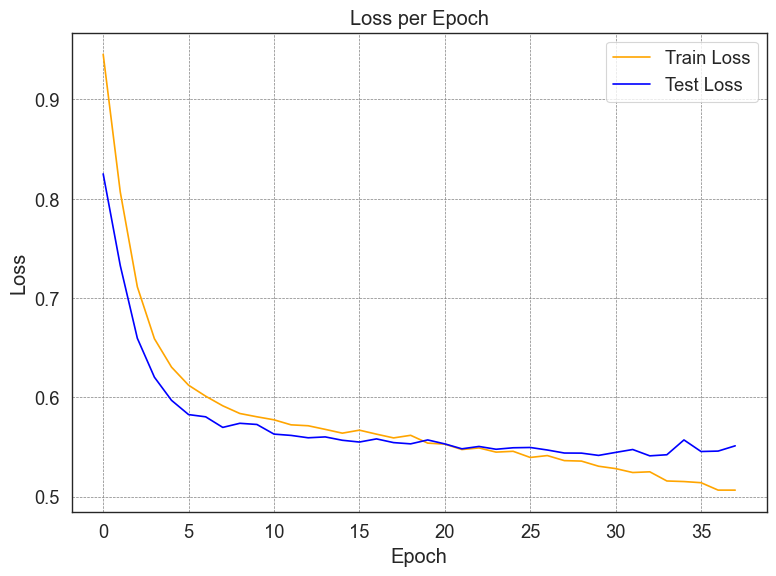

Model Parameters:
embedding_layer.weight                   -> (3608, 100)
lstm.weight_ih_l0                        -> (512, 100)
lstm.weight_hh_l0                        -> (512, 128)
lstm.bias_ih_l0                          -> (512,)
lstm.bias_hh_l0                          -> (512,)
lstm.weight_ih_l0_reverse                -> (512, 100)
lstm.weight_hh_l0_reverse                -> (512, 128)
lstm.bias_ih_l0_reverse                  -> (512,)
lstm.bias_hh_l0_reverse                  -> (512,)
lstm.weight_ih_l1                        -> (512, 256)
lstm.weight_hh_l1                        -> (512, 128)
lstm.bias_ih_l1                          -> (512,)
lstm.bias_hh_l1                          -> (512,)
lstm.weight_ih_l1_reverse                -> (512, 256)
lstm.weight_hh_l1_reverse                -> (512, 128)
lstm.bias_ih_l1_reverse                  -> (512,)
lstm.bias_hh_l1_reverse                  -> (512,)
attn.0.weight                            -> (64, 256)
attn.0.bias             

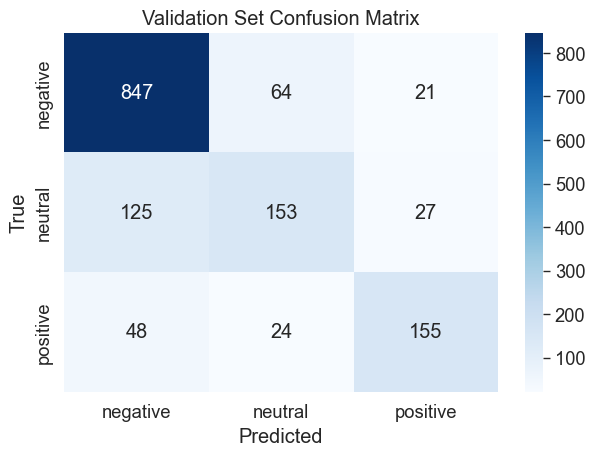


--------------------------Test Set--------------------------
              precision    recall  f1-score   support

    negative     0.8241    0.9041    0.8623      1835
     neutral     0.6233    0.5177    0.5656       620
    positive     0.7350    0.6216    0.6735       473

    accuracy                         0.7766      2928
   macro avg     0.7275    0.6811    0.7005      2928
weighted avg     0.7672    0.7766    0.7690      2928



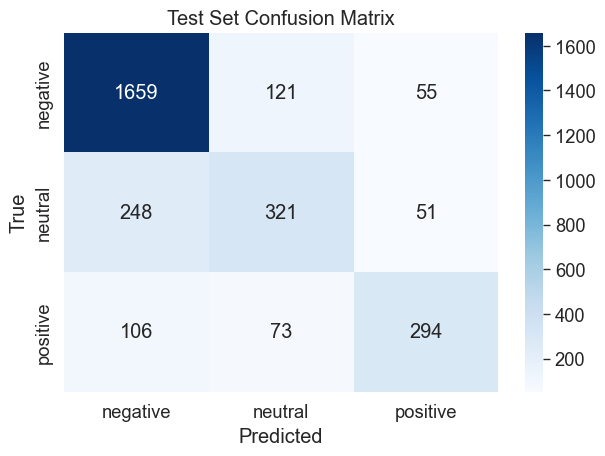

In [ ]:
# =============================================================================
# Model Training and Testing - With Attention Layer
# =============================================================================

# Actual training
wa_model, \
    wa_train_loss, \
    wa_train_acc, \
    wa_test_loss, \
    wa_test_acc, \
    wa_train_test_predictions = train_model(wa_model,
                                            train_loader,
                                            val_loader,
                                            criterion,
                                            wa_optimizer,
                                            epochs,
                                            patience=5 )

# Plot the training history
plot_training_history(wa_train_loss, wa_test_loss)

# Get predictions for the training set
wa_test_preds, wa_test_actuals = get_predictions(wa_model, test_loader)

# Get prediction for the test set
wa_val_preds, wa_val_actuals = get_predictions(wa_model, val_loader)

# Network Parameters
report_model_parameters(wa_model)

# Validation metrics
report_validation_metrics(wa_val_actuals, wa_val_preds, case='With Attention Layer - Validation Set')
report_validation_metrics(wa_test_actuals, wa_test_preds, case='With Attention Layer - Test Set')


### Analysis without Attention Layer

Epoch [1/200], 
 Train Loss:   0.965082 | Train Acc:    0.623536
 Test Loss:    0.859378 |  Test Acc:     0.636612
Model improved.!
Epoch [2/200], 
 Train Loss:   0.837318 | Train Acc:    0.625585
 Test Loss:    0.772115 |  Test Acc:     0.636612
Model improved.!
Epoch [3/200], 
 Train Loss:   0.768856 | Train Acc:    0.632806
 Test Loss:    0.724422 |  Test Acc:     0.669399
Model improved.!
Epoch [4/200], 
 Train Loss:   0.725167 | Train Acc:    0.676815
 Test Loss:    0.692870 |  Test Acc:     0.706284
Model improved.!
Epoch [5/200], 
 Train Loss:   0.695016 | Train Acc:    0.711944
 Test Loss:    0.677318 |  Test Acc:     0.719262
Model improved.!
Epoch [6/200], 
 Train Loss:   0.676820 | Train Acc:    0.710870
 Test Loss:    0.648994 |  Test Acc:     0.739071
Model improved.!
Epoch [7/200], 
 Train Loss:   0.657464 | Train Acc:    0.729411
 Test Loss:    0.641075 |  Test Acc:     0.743852
Model improved.!
Epoch [8/200], 
 Train Loss:   0.647811 | Train Acc:    0.732631
 Test Loss:

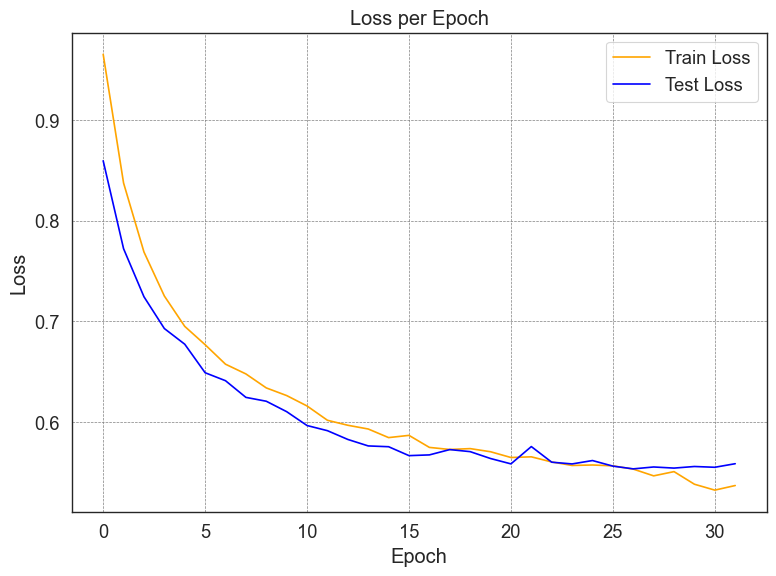

Model Parameters:
embedding_layer.weight                   -> (3608, 100)
lstm.weight_ih_l0                        -> (512, 100)
lstm.weight_hh_l0                        -> (512, 128)
lstm.bias_ih_l0                          -> (512,)
lstm.bias_hh_l0                          -> (512,)
lstm.weight_ih_l0_reverse                -> (512, 100)
lstm.weight_hh_l0_reverse                -> (512, 128)
lstm.bias_ih_l0_reverse                  -> (512,)
lstm.bias_hh_l0_reverse                  -> (512,)
lstm.weight_ih_l1                        -> (512, 256)
lstm.weight_hh_l1                        -> (512, 128)
lstm.bias_ih_l1                          -> (512,)
lstm.bias_hh_l1                          -> (512,)
lstm.weight_ih_l1_reverse                -> (512, 256)
lstm.weight_hh_l1_reverse                -> (512, 128)
lstm.bias_ih_l1_reverse                  -> (512,)
lstm.bias_hh_l1_reverse                  -> (512,)
attn.0.weight                            -> (64, 256)
attn.0.bias             

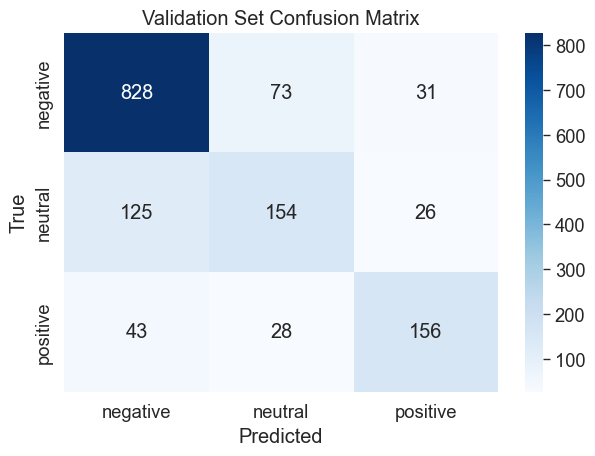


--------------------------Test Set--------------------------
              precision    recall  f1-score   support

    negative     0.8260    0.8850    0.8545      1835
     neutral     0.5935    0.5323    0.5612       620
    positive     0.7241    0.6216    0.6689       473

    accuracy                         0.7678      2928
   macro avg     0.7146    0.6796    0.6949      2928
weighted avg     0.7603    0.7678    0.7624      2928



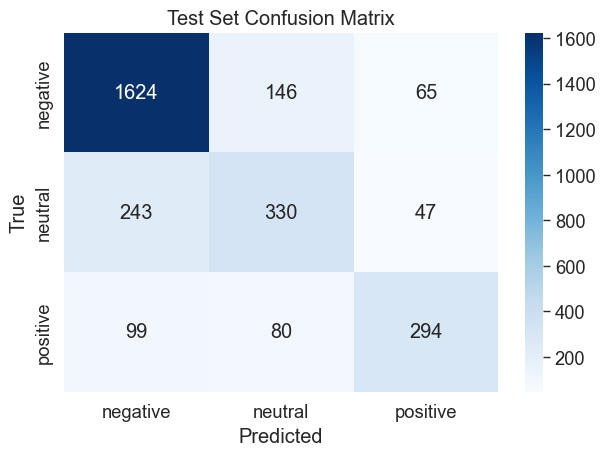

In [ ]:
# =============================================================================
# Model Training and Testing - Without Attention Layer (na)
# =============================================================================

na_model, \
    na_train_loss, \
    na_train_acc, \
    na_test_loss, \
    na_test_acc, \
    na_train_test_predictions = train_model(na_model,
                                        train_loader,
                                        val_loader,
                                        criterion,
                                        na_optimizer,
                                        epochs,
                                        patience=5 )
# Plot the training history
plot_training_history(na_train_loss, na_test_loss)

# Get predictions for the training set
na_test_preds, na_test_actuals = get_predictions(na_model, test_loader)

# Get prediction for the test set
na_val_preds, na_val_actuals = get_predictions(na_model, val_loader)

# Network Parameters
report_model_parameters(na_model)

# Validation metrics of
report_validation_metrics(na_val_actuals, na_val_preds,  case='No Attention Layer - Validation Set')
report_validation_metrics(na_test_actuals, na_test_preds, case='No Attention Layer - Test Set')

In [19]:
# Save Models
torch.save({
    'na_model_state_dict': na_model.state_dict(),
    'wa_model_state_dict': wa_model.state_dict(),
    'word2id': word2id,
    'embedding_matrix': embedding_matrix,
    'config': {
        'hidden_dim': 128,
        'output_dim': 3,
        'num_layers': 2,
        'max_len': 40,
    },
}, 'bilstm_attention_full_bundle.pt')

## Discussion 

Attention didn't just shift toward majority class (which would hurt macro-F1).
It made each class slightly more balanced internally — the precision/recall
trade-off improved across the board.


The Bi-LSTM with attention achieved 
- 77.7% accuracy and 
- 0.700 macro-F1,

The bi-LSTM without attention achieved
- 76.8% accuracy
- and 0.695 macro-F1 
 
Overall the two model achieved similar results. Improvements were modest from the model with no attention layer to model with attention layer, but consistent across all classes and metrics. The largest gains came from negative recall (+1.9 points) and neutral precision (+2.9 points), suggesting that attention helped the model both detect majority-class instances more reliably and become more discriminating about minority-class predictions. 


Beyond the accuracy improvements, the attention model converged more slowly than the baseline, reflecting the extra parameters and the need to learn attention weights in addition to LSTM representations.